In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.ndimage import binary_dilation

In [3]:
# Load the .ply file as a legacy TriangleMesh
mesh_legacy = o3d.io.read_triangle_mesh("stata_03.ply")
mesh_legacy.compute_vertex_normals()  # Optional but often useful

print("Number of vertices:", len(mesh_legacy.vertices))
print("Number of triangles:", len(mesh_legacy.triangles))

Number of vertices: 116382
Number of triangles: 38794


In [4]:
# Convert the legacy mesh to a tensor-based mesh for raycasting
mesh_tensor = o3d.t.geometry.TriangleMesh.from_legacy(mesh_legacy)

# Create a raycasting scene and add the mesh
scene = o3d.t.geometry.RaycastingScene()
scene.add_triangles(mesh_tensor)

0

Avg. time per raycast: 0.00008 seconds


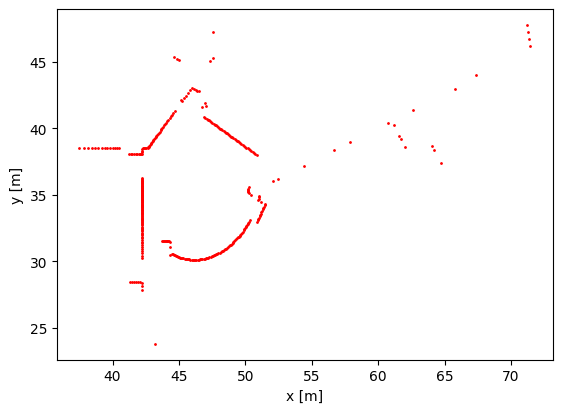

In [6]:
scene_origin = np.array([45, 35, 8], dtype=np.float32)
directions = np.deg2rad(np.arange(-180, 180, 1, dtype=np.float32))
directions_vectors = np.column_stack(
    (np.cos(directions), np.sin(directions), np.zeros_like(directions))
)

raycast_vectors = np.column_stack(
    (scene_origin[None, :] * np.ones_like(directions_vectors), directions_vectors)
)

n_trials = 1_000
start = perf_counter()
for _ in range(n_trials):
    ans = scene.cast_rays(raycast_vectors)
t_elapsed = perf_counter() - start
print(f"Avg. time per raycast: {t_elapsed/n_trials:.5f} seconds")

t_hit = ans['t_hit'].numpy()
t_hit_noise = np.random.normal(0, 0.0254, size=t_hit.shape)
# t_hit = t_hit + t_hit_noise

hit = t_hit < np.inf

points = raycast_vectors[hit][:, :3] + raycast_vectors[hit][:, 3: ] * t_hit[hit].reshape((-1, 1))

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.scatter(points[:, 0], points[:, 1], c='r', s=1)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
plt.show()

In [47]:
og = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
])

def check_occupancy_surrounding(arr: np.ndarray, i: int, j: int):
    H, W = arr.shape
    
    above, below, left, right = True, True, True, True
    
    if i == 0:
        above = False
    if i == H-1:
        below = False
    
    if j == 0:
        left = False
    if j == W-1:
        right = False
    
class ArrayMap:
    def __init__(self, arr: np.ndarray):
        self.arr = np.pad(arr, pad_width=1, mode='constant', constant_values=0)
        self.H, self.W = arr.shape
        
        structure = np.ones((3, 3), dtype=int)
        dilated = binary_dilation(self.arr, structure=structure).astype(int)
        self.walls = dilated - self.arr

am = ArrayMap(og)
print(am.walls)

[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0]
 [0 0 0 1 0 0 0 0 1 0 0]
 [0 1 1 1 0 0 0 1 1 0 0]
 [0 1 0 0 0 0 0 1 0 0 0]
 [0 1 1 1 1 0 1 1 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


In [40]:
from scipy.ndimage import binary_dilation

og = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
])

structure = np.ones((3, 3), dtype=int)
dilated = binary_dilation(og, structure=structure).astype(int)

In [42]:
dilated - og

array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 1, 0, 0],
       [1, 1, 1, 0, 1, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]])